In [168]:
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    cross_val_score,
    train_test_split,
    validation_curve,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

In [169]:
from ucimlrepo import fetch_ucirepo

In [170]:
MISSING_STRING_VALUES = {"", "?", "nan", "none", "null"}

In [171]:
NUMERIC_COLS = [
    "age",
    "balance",
    "day_of_week",
    "duration",
    "campaign",
    "pdays",
    "previous",
]

CATEGORICAL_COLS = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
]

TARGET_COL = "y"
TARGET_MAP = {"yes": 1, "no": 0}
VIS_DIR = Path("vis")
VIS_DIR.mkdir(exist_ok=True)

In [172]:
def load_data() -> pd.DataFrame:
    """Fetch the Bank Marketing dataset and return one combined DataFrame."""
    bank_marketing = fetch_ucirepo(id=222)

    X = bank_marketing.data.features.copy()
    y = bank_marketing.data.targets.copy()

    df = pd.concat([X, y], axis=1)
    return df

In [173]:
def validate_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean column types, standardize missing markers, and map the target."""
    df = df.copy()
    df.columns = df.columns.str.strip()

    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in CATEGORICAL_COLS:
        df[col] = df[col].astype("object")
        df[col] = df[col].where(~pd.isna(df[col]), np.nan)
        df[col] = df[col].map(lambda value: value.strip() if isinstance(value, str) else value)
        df[col] = df[col].replace(list(MISSING_STRING_VALUES), np.nan)

    df[TARGET_COL] = df[TARGET_COL].astype("object")
    df[TARGET_COL] = df[TARGET_COL].where(~pd.isna(df[TARGET_COL]), np.nan)
    df[TARGET_COL] = df[TARGET_COL].map(
        lambda value: value.strip().lower() if isinstance(value, str) else value
    )
    df[TARGET_COL] = df[TARGET_COL].replace(list(MISSING_STRING_VALUES), np.nan)
    df[TARGET_COL] = df[TARGET_COL].map(TARGET_MAP).astype("Int64")

    return df


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add the engineered features used in the comparison."""
    df = df.copy()
    df["previously_contacted"] = (df["pdays"] >= 0).astype(int)
    df["age_group"] = pd.cut(
        df["age"],
        bins=[0, 30, 45, 60, 100],
        labels=["18-30", "31-45", "46-60", "60+"],
    )
    df["campaign_ratio_previous"] = df["campaign"] / (df["previous"] + 1)
    return df

In [174]:
def get_feature_types(df: pd.DataFrame, target_col: str = TARGET_COL) -> tuple[list[str], list[str], list[str]]:
    """Return feature, numeric, and categorical column lists for modeling."""
    feature_cols = [col for col in df.columns if col != target_col]
    numeric_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df[col])]
    categorical_cols = [col for col in feature_cols if col not in numeric_cols]
    return feature_cols, numeric_cols, categorical_cols

In [175]:
def split_data(
    df: pd.DataFrame,
    target_col: str = TARGET_COL,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
):
    """Create stratified train, validation, and test splits."""
    if round(train_size + val_size + test_size, 5) != 1.0:
        raise ValueError("train_size + val_size + test_size must sum to 1.0")

    X = df.drop(columns=target_col)
    y = df[target_col]

    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=(1 - train_size),
        stratify=y,
        random_state=random_state,
    )

    relative_test_size = test_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=relative_test_size,
        stratify=y_temp,
        random_state=random_state,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [176]:
def build_preprocessor(
    numeric_cols: list[str],
    categorical_cols: list[str],
    scale_numeric: bool = False,
) -> ColumnTransformer:
    """Build a train-only preprocessing pipeline for either GBDT or MLP."""
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=numeric_steps), numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )

    return preprocessor

In [177]:
def build_model_pipeline(
    numeric_cols: list[str],
    categorical_cols: list[str],
    scale_numeric: bool,
    model,
) -> Pipeline:
    """Wrap preprocessing and an estimator into one leakage-safe pipeline."""
    return Pipeline(
        steps=[
            (
                "preprocessor",
                build_preprocessor(
                    numeric_cols=numeric_cols,
                    categorical_cols=categorical_cols,
                    scale_numeric=scale_numeric,
                ),
            ),
            ("model", model),
        ]
    )

In [178]:
def preprocess_data(
    df: pd.DataFrame,
    use_engineered_features: bool = True,
    random_state: int = 42,
) -> dict:
    """Run the full preprocessing workflow for both GBDT and MLP."""
    cleaned_df = validate_data(df)

    if use_engineered_features:
        cleaned_df = add_engineered_features(cleaned_df)

    feature_cols, numeric_cols, categorical_cols = get_feature_types(cleaned_df)

    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        cleaned_df,
        target_col=TARGET_COL,
        random_state=random_state,
    )

    gbdt_preprocessor = build_preprocessor(
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        scale_numeric=False,
    )
    mlp_preprocessor = build_preprocessor(
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        scale_numeric=True,
    )

    X_train_gbdt = gbdt_preprocessor.fit_transform(X_train)
    X_val_gbdt = gbdt_preprocessor.transform(X_val)
    X_test_gbdt = gbdt_preprocessor.transform(X_test)

    X_train_mlp = mlp_preprocessor.fit_transform(X_train)
    X_val_mlp = mlp_preprocessor.transform(X_val)
    X_test_mlp = mlp_preprocessor.transform(X_test)

    return {
        "cleaned_df": cleaned_df,
        "feature_names": feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "splits": {
            "X_train": X_train,
            "X_val": X_val,
            "X_test": X_test,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test,
        },
        "gbdt": {
            "preprocessor": gbdt_preprocessor,
            "X_train": X_train_gbdt,
            "X_val": X_val_gbdt,
            "X_test": X_test_gbdt,
        },
        "mlp": {
            "preprocessor": mlp_preprocessor,
            "X_train": X_train_mlp,
            "X_val": X_val_mlp,
            "X_test": X_test_mlp,
        },
    }


def tune_gbdt_hyperparameters(
    X_train,
    y_train,
    X_val,
    y_val,
    numeric_cols: list[str],
    categorical_cols: list[str],
) -> tuple[pd.DataFrame, dict, Pipeline]:
    """Tune GBDT hyperparameters on the train/validation split."""
    param_grid = {
        "model__learning_rate": [0.01, 0.1, 0.3],
        "model__n_estimators": [100, 300],
        "model__max_depth": [3, 6],
        "model__subsample": [0.8, 1.0],
        "model__reg_alpha": [0.0, 0.1, 0.5],
        "model__reg_lambda": [0.5, 1.0, 5.0],
    }

    base_pipeline = build_model_pipeline(
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        scale_numeric=False,
        model=XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            colsample_bytree=1.0,
            random_state=42,
        ),
    )

    grid_search = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=3,
        n_jobs=-1,
        refit=True,
    )

    start_time = time.time()
    grid_search.fit(X_train, y_train)
    total_search_time = time.time() - start_time

    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df = results_df[
        [
            "param_model__learning_rate",
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__subsample",
            "param_model__reg_alpha",
            "param_model__reg_lambda",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
        ]
    ].rename(
        columns={
            "param_model__learning_rate": "learning_rate",
            "param_model__n_estimators": "n_estimators",
            "param_model__max_depth": "max_depth",
            "param_model__subsample": "subsample",
            "param_model__reg_alpha": "reg_alpha",
            "param_model__reg_lambda": "reg_lambda",
            "mean_test_score": "cv_f1",
            "std_test_score": "cv_f1_std",
        }
    )

    best_pipeline = grid_search.best_estimator_
    best_params = {
        key.replace("model__", ""): value for key, value in grid_search.best_params_.items()
    }
    y_val_pred = best_pipeline.predict(X_val)
    y_val_proba = best_pipeline.predict_proba(X_val)[:, 1]

    best_metrics = {
        **best_params,
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred, zero_division=0),
        "recall": recall_score(y_val, y_val_pred, zero_division=0),
        "f1": f1_score(y_val, y_val_pred, zero_division=0),
        "auc_pr": average_precision_score(y_val, y_val_proba),
        "train_time_sec": grid_search.refit_time_,
        "search_time_sec": total_search_time,
    }

    validation_rows = []
    raw_param_grid = {
        "learning_rate": [0.01, 0.1, 0.3],
        "n_estimators": [100, 300],
        "max_depth": [3, 6],
        "subsample": [0.8, 1.0],
        "reg_alpha": [0.0, 0.1, 0.5],
        "reg_lambda": [0.5, 1.0, 5.0],
    }
    for params in ParameterGrid(raw_param_grid):
        pipeline = build_model_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            scale_numeric=False,
            model=XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                colsample_bytree=1.0,
                random_state=42,
                **params,
            ),
        )
        train_start_time = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - train_start_time

        y_train_pred = pipeline.predict(X_train)
        y_val_pred = pipeline.predict(X_val)
        y_val_proba = pipeline.predict_proba(X_val)[:, 1]

        validation_rows.append(
            {
                **params,
                "train_accuracy": accuracy_score(y_train, y_train_pred),
                "train_f1": f1_score(y_train, y_train_pred, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_pred),
                "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0),
                "f1": f1_score(y_val, y_val_pred, zero_division=0),
                "auc_pr": average_precision_score(y_val, y_val_proba),
                "train_time_sec": train_time,
            }
        )

    validation_results_df = pd.DataFrame(validation_rows)
    results_df = results_df.merge(
        validation_results_df,
        on=["learning_rate", "n_estimators", "max_depth", "subsample", "reg_alpha", "reg_lambda"],
        how="left",
    )
    results_df = results_df.sort_values(["f1", "auc_pr"], ascending=False).reset_index(drop=True)

    return results_df, best_metrics, best_pipeline

In [179]:
def summarize_gbdt_parameter_effects(results_df: pd.DataFrame, parameter_name: str) -> pd.DataFrame:
    """Summarize how one GBDT hyperparameter affects performance and overfitting."""
    summary_df = (
        results_df.groupby(parameter_name, as_index=False)
        .agg(
            mean_train_f1=("train_f1", "mean"),
            mean_val_f1=("f1", "mean"),
            mean_val_auc_pr=("auc_pr", "mean"),
            mean_precision=("precision", "mean"),
            mean_recall=("recall", "mean"),
        )
        .round(4)
    )
    summary_df["overfit_gap_f1"] = (
        summary_df["mean_train_f1"] - summary_df["mean_val_f1"]
    ).round(4)
    return summary_df

In [180]:
def plot_gbdt_parameter_summary_table(summary_df: pd.DataFrame, parameter_name: str):
    """Render one GBDT parameter-effect summary as a matplotlib table."""
    fig, ax = plt.subplots(figsize=(11, 2.6))
    ax.axis("off")
    table = ax.table(
        cellText=summary_df.values,
        colLabels=summary_df.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)
    ax.set_title(f"GBDT Parameter Effect Summary: {parameter_name}", pad=12)
    plt.tight_layout()
    plt.savefig(
        VIS_DIR / f"gbdt_parameter_summary_{parameter_name}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

In [181]:
def tune_decision_threshold(
    y_true,
    y_proba,
    thresholds: list[float],
) -> tuple[pd.DataFrame, dict]:
    """Evaluate multiple probability thresholds on the validation set."""
    threshold_results = []
    best_result = None

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        result = {
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "auc_pr": average_precision_score(y_true, y_proba),
        }
        threshold_results.append(result)

        if (
            best_result is None
            or result["f1"] > best_result["f1"]
            or (
                result["f1"] == best_result["f1"]
                and result["auc_pr"] > best_result["auc_pr"]
            )
        ):
            best_result = result

    results_df = pd.DataFrame(threshold_results).sort_values("threshold").reset_index(drop=True)
    return results_df, best_result

In [182]:
def tune_mlp_hyperparameters(
    X_train,
    y_train,
    X_val,
    y_val,
    numeric_cols: list[str],
    categorical_cols: list[str],
) -> tuple[pd.DataFrame, dict, Pipeline]:
    """Tune MLP hyperparameters on the train/validation split."""
    param_grid = {
        "model__hidden_layer_sizes": [(64,), (128, 64), (256, 128, 64)],
        "model__activation": ["relu", "tanh"],
        "model__learning_rate_init": [0.001, 0.01, 0.1],
        "model__max_iter": [300, 600],
    }

    base_pipeline = build_model_pipeline(
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        scale_numeric=True,
        model=MLPClassifier(
            early_stopping=True,
            random_state=42,
        ),
    )

    grid_search = GridSearchCV(
        estimator=base_pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=3,
        n_jobs=-1,
        refit=True,
    )

    start_time = time.time()
    grid_search.fit(X_train, y_train)
    total_search_time = time.time() - start_time

    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df = results_df[
        [
            "param_model__hidden_layer_sizes",
            "param_model__activation",
            "param_model__learning_rate_init",
            "param_model__max_iter",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
        ]
    ].rename(
        columns={
            "param_model__hidden_layer_sizes": "hidden_layer_sizes",
            "param_model__activation": "activation",
            "param_model__learning_rate_init": "learning_rate_init",
            "param_model__max_iter": "max_iter",
            "mean_test_score": "cv_f1",
            "std_test_score": "cv_f1_std",
        }
    )

    best_pipeline = grid_search.best_estimator_
    best_params = {
        key.replace("model__", ""): value for key, value in grid_search.best_params_.items()
    }
    y_train_pred = best_pipeline.predict(X_train)
    y_val_pred = best_pipeline.predict(X_val)
    y_val_proba = best_pipeline.predict_proba(X_val)[:, 1]

    best_metrics = {
        **best_params,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_f1": f1_score(y_train, y_train_pred, zero_division=0),
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred, zero_division=0),
        "recall": recall_score(y_val, y_val_pred, zero_division=0),
        "f1": f1_score(y_val, y_val_pred, zero_division=0),
        "auc_pr": average_precision_score(y_val, y_val_proba),
        "train_time_sec": grid_search.refit_time_,
        "search_time_sec": total_search_time,
    }

    validation_rows = []
    raw_param_grid = {
        "hidden_layer_sizes": [(64,), (128, 64), (256, 128, 64)],
        "activation": ["relu", "tanh"],
        "learning_rate_init": [0.001, 0.01, 0.1],
        "max_iter": [300, 600],
    }
    for params in ParameterGrid(raw_param_grid):
        pipeline = build_model_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            scale_numeric=True,
            model=MLPClassifier(
                early_stopping=True,
                random_state=42,
                **params,
            ),
        )
        train_start_time = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - train_start_time
        y_train_pred = pipeline.predict(X_train)
        y_val_pred = pipeline.predict(X_val)
        y_val_proba = pipeline.predict_proba(X_val)[:, 1]

        validation_rows.append(
            {
                **params,
                "train_accuracy": accuracy_score(y_train, y_train_pred),
                "train_f1": f1_score(y_train, y_train_pred, zero_division=0),
                "accuracy": accuracy_score(y_val, y_val_pred),
                "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0),
                "f1": f1_score(y_val, y_val_pred, zero_division=0),
                "auc_pr": average_precision_score(y_val, y_val_proba),
                "train_time_sec": train_time,
            }
        )

    validation_results_df = pd.DataFrame(validation_rows)
    results_df = results_df.merge(
        validation_results_df,
        on=["hidden_layer_sizes", "activation", "learning_rate_init", "max_iter"],
        how="left",
    )
    results_df = results_df.sort_values(["f1", "auc_pr"], ascending=False).reset_index(drop=True)

    return results_df, best_metrics, best_pipeline

In [183]:
def evaluate_model_on_test_set(model, X_test, y_test, threshold: float = 0.5) -> dict:
    """Evaluate a trained model once on the test set."""
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred, zero_division=0),
        "recall": recall_score(y_test, y_test_pred, zero_division=0),
        "f1": f1_score(y_test, y_test_pred, zero_division=0),
        "auc_pr": average_precision_score(y_test, y_test_proba),
    }

In [184]:
def build_comparison_table(gbdt_results: dict, mlp_results: dict) -> pd.DataFrame:
    """Build a side-by-side final comparison table."""
    comparison_df = pd.DataFrame(
        [
            {"model": "GBDT", **gbdt_results},
            {"model": "MLP", **mlp_results},
        ]
    )
    column_order = [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc_pr",
        "train_time_sec",
    ]
    comparison_df = comparison_df[column_order].round(4)
    return comparison_df

In [185]:
def plot_comparison_table(comparison_df: pd.DataFrame, title: str = "GBDT vs MLP Comparison"):
    """Render the final comparison table as a matplotlib figure."""
    fig, ax = plt.subplots(figsize=(10, 2.5))
    ax.axis("off")
    table = ax.table(
        cellText=comparison_df.values,
        colLabels=comparison_df.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    ax.set_title(title, pad=12)
    plt.tight_layout()
    fig.savefig(VIS_DIR / "final_comparison_table.png", dpi=300, bbox_inches="tight")
    plt.show()

In [186]:
def summarize_final_model_comparison(comparison_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize which final model leads on each metric and on training time."""
    summary_rows = []
    metric_directions = {
        "accuracy": "max",
        "precision": "max",
        "recall": "max",
        "f1": "max",
        "auc_pr": "max",
        "train_time_sec": "min",
    }

    for metric_name, direction in metric_directions.items():
        if direction == "max":
            best_idx = comparison_df[metric_name].idxmax()
        else:
            best_idx = comparison_df[metric_name].idxmin()

        summary_rows.append(
            {
                "metric": metric_name,
                "best_model": comparison_df.loc[best_idx, "model"],
                "best_value": round(comparison_df.loc[best_idx, metric_name], 4),
            }
        )

    return pd.DataFrame(summary_rows)


def format_transformed_feature_name(feature_name: str, categorical_cols: list[str]) -> str:
    """Convert transformed column names into cleaner plot labels."""
    clean_name = feature_name
    for prefix in ("num__", "cat__", "remainder__", "imputer__", "scaler__", "onehot__"):
        if clean_name.startswith(prefix):
            clean_name = clean_name[len(prefix):]

    for col in sorted(categorical_cols, key=len, reverse=True):
        column_prefix = f"{col}_"
        if clean_name.startswith(column_prefix):
            return f"{col} = {clean_name[len(column_prefix):]}"

    return clean_name


def get_transformed_feature_names(
    preprocessor: ColumnTransformer,
    categorical_cols: list[str],
) -> list[str]:
    """Return readable transformed feature names from a fitted preprocessor."""
    raw_feature_names = preprocessor.get_feature_names_out()
    return [
        format_transformed_feature_name(feature_name, categorical_cols)
        for feature_name in raw_feature_names
    ]


def plot_named_feature_importance(
    model: XGBClassifier,
    feature_names: list[str],
    max_num_features: int = 15,
):
    """Plot GBDT feature importances using readable names and rounded labels."""
    importance_by_feature_id = model.get_booster().get_score(importance_type="gain")

    importance_rows = []
    for feature_id, importance_value in importance_by_feature_id.items():
        feature_index = int(feature_id[1:])
        importance_rows.append(
            {
                "feature": feature_names[feature_index],
                "importance": float(importance_value),
            }
        )

    importance_df = (
        pd.DataFrame(importance_rows)
        .sort_values("importance", ascending=False)
        .head(max_num_features)
        .sort_values("importance", ascending=True)
        .reset_index(drop=True)
    )

    fig_height = max(6, 0.5 * len(importance_df) + 1)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    bars = ax.barh(importance_df["feature"], importance_df["importance"], color="#2c6fb7")

    max_importance = importance_df["importance"].max()
    label_offset = max_importance * 0.01 if max_importance > 0 else 0.01

    for bar, importance_value in zip(bars, importance_df["importance"]):
        ax.text(
            bar.get_width() + label_offset,
            bar.get_y() + bar.get_height() / 2,
            f"{importance_value:.2f}",
            va="center",
        )

    ax.set_title("GBDT Feature Importance")
    ax.set_xlabel("Importance score")
    ax.set_ylabel("Features")
    ax.grid(True, axis="x", alpha=0.3)
    ax.set_xlim(0, max_importance * 1.12 if max_importance > 0 else 1)
    fig.tight_layout()
    fig.savefig(VIS_DIR / "gbdt_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()


def fit_gbdt_with_monitoring(X_train, y_train, X_val, y_val, params: dict, early_stopping_rounds: int = 20):
    """Fit a GBDT model with eval_set monitoring and early stopping."""
    monitoring_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        colsample_bytree=1.0,
        random_state=42,
        early_stopping_rounds=early_stopping_rounds,
        **params,
    )
    monitoring_model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )
    return monitoring_model

In [187]:
loaded_df = load_data()
print("Raw data preview:")
print(loaded_df.head())

df = validate_data(loaded_df)
print("\nValidated data preview:")
print(df.head())

print("\nColumn dtypes:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

print("\nTarget distribution:")
print(df[TARGET_COL].value_counts(dropna=False))

engineered_df = add_engineered_features(df)
print("\nEngineered data preview:")
print(engineered_df.head())

print("\nEngineered feature check:")
print(
    engineered_df[
        [
            "pdays",
            "previously_contacted",
            "age",
            "age_group",
            "campaign",
            "previous",
            "campaign_ratio_previous",
        ]
    ].head(10)
)

Raw data preview:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome   y  
0     NaN            5   may       261         1     -1         0      NaN  no  
1     NaN            5   may       151         1     -1         0      NaN  no  
2     NaN            5   may        76         1     -1         0      NaN  no  
3     NaN            5   may        92         1     -1         0      NaN  no  
4     NaN            5   may       198         1     -1         0      NaN  no  

Validated data preview:
   age           job  mari

In [188]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(engineered_df)

feature_cols, numeric_cols, categorical_cols = get_feature_types(engineered_df)

gbdt_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    scale_numeric=False,
)
mlp_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    scale_numeric=True,
)

X_train_gbdt = gbdt_preprocessor.fit_transform(X_train)
X_val_gbdt = gbdt_preprocessor.transform(X_val)
X_test_gbdt = gbdt_preprocessor.transform(X_test)

X_train_mlp = mlp_preprocessor.fit_transform(X_train)
X_val_mlp = mlp_preprocessor.transform(X_val)
X_test_mlp = mlp_preprocessor.transform(X_test)

print("\nSplit sizes:")
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

print("\nTarget distribution by split:")
print("Train")
print(y_train.value_counts(normalize=True))
print("Validation")
print(y_val.value_counts(normalize=True))
print("Test")
print(y_test.value_counts(normalize=True))

print("\nTransformed feature shapes:")
print("GBDT:", X_train_gbdt.shape, X_val_gbdt.shape, X_test_gbdt.shape)
print("MLP:", X_train_mlp.shape, X_val_mlp.shape, X_test_mlp.shape)


Split sizes:
(31647, 19) (6782, 19) (6782, 19)
(31647,) (6782,) (6782,)

Target distribution by split:
Train
y
0    0.883022
1    0.116978
Name: proportion, dtype: Float64
Validation
y
0    0.882925
1    0.117075
Name: proportion, dtype: Float64
Test
y
0    0.883073
1    0.116927
Name: proportion, dtype: Float64

Transformed feature shapes:
GBDT: (31647, 57) (6782, 57) (6782, 57)
MLP: (31647, 57) (6782, 57) (6782, 57)


In [189]:
gbdt_baseline = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
)

print(gbdt_baseline)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


In [190]:
start_time = time.time()

gbdt_baseline.fit(
    X_train_gbdt,
    y_train,
    eval_set=[(X_train_gbdt, y_train), (X_val_gbdt, y_val)],
    verbose=False,
)

gbdt_train_time = time.time() - start_time

print(f"Baseline GBDT training time: {gbdt_train_time:.4f} seconds")

Baseline GBDT training time: 0.7183 seconds


In [191]:
y_train_pred_gbdt = gbdt_baseline.predict(X_train_gbdt)
y_val_pred_gbdt = gbdt_baseline.predict(X_val_gbdt)
y_val_proba_gbdt = gbdt_baseline.predict_proba(X_val_gbdt)[:, 1]

gbdt_train_accuracy = accuracy_score(y_train, y_train_pred_gbdt)

gbdt_val_metrics = {
    "accuracy": accuracy_score(y_val, y_val_pred_gbdt),
    "precision": precision_score(y_val, y_val_pred_gbdt, zero_division=0),
    "recall": recall_score(y_val, y_val_pred_gbdt, zero_division=0),
    "f1": f1_score(y_val, y_val_pred_gbdt, zero_division=0),
    "auc_pr": average_precision_score(y_val, y_val_proba_gbdt),
}

print(f"Baseline GBDT training accuracy: {gbdt_train_accuracy:.4f}")

print("\nBaseline GBDT validation metrics:")
for metric_name, metric_value in gbdt_val_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Baseline GBDT training accuracy: 0.9577

Baseline GBDT validation metrics:
accuracy: 0.9101
precision: 0.6603
recall: 0.4773
f1: 0.5541
auc_pr: 0.6393


In [192]:
gbdt_tuning_results_df, gbdt_best_metrics, gbdt_best_model = tune_gbdt_hyperparameters(
    X_train,
    y_train,
    X_val,
    y_val,
    numeric_cols,
    categorical_cols,
)

print("Top 5 tuned GBDT runs by validation F1:")
print(gbdt_tuning_results_df.head(5))

print("\nBest tuned GBDT result:")
print(gbdt_best_metrics)

Top 5 tuned GBDT runs by validation F1:
   learning_rate  n_estimators  max_depth  subsample  reg_alpha  reg_lambda  \
0            0.1           300          6        0.8        0.5         5.0   
1            0.1           300          6        0.8        0.1         5.0   
2            0.3           100          6        1.0        0.1         5.0   
3            0.3           300          3        0.8        0.5         1.0   
4            0.3           300          6        1.0        0.5         1.0   

      cv_f1  cv_f1_std  rank_test_score  train_accuracy  train_f1  accuracy  \
0  0.544794   0.011656               31        0.956520  0.796209  0.912268   
1  0.551927   0.005046                3        0.957626  0.802183  0.911236   
2  0.554265   0.005201                1        0.951465  0.772174  0.910793   
3  0.541899   0.009681               57        0.935191  0.688912  0.912120   
4  0.536066   0.006842               89        0.992701  0.968045  0.910498   

   precisi


GBDT parameter effect summary: learning_rate
   learning_rate  mean_train_f1  mean_val_f1  mean_val_auc_pr  mean_precision  \
0           0.01         0.2703       0.2518           0.5933          0.8184   
1           0.10         0.6546       0.5355           0.6357          0.6751   
2           0.30         0.7656       0.5483           0.6213          0.6509   

   mean_recall  overfit_gap_f1  
0       0.1718          0.0185  
1       0.4454          0.1191  
2       0.4743          0.2173  


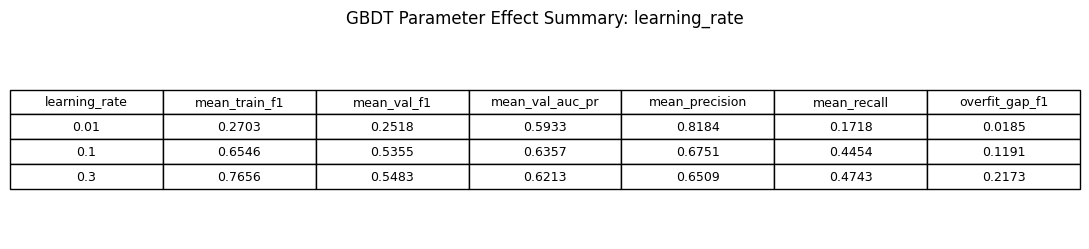


GBDT parameter effect summary: n_estimators
   n_estimators  mean_train_f1  mean_val_f1  mean_val_auc_pr  mean_precision  \
0           100         0.4705       0.3880           0.6131          0.7527   
1           300         0.6565       0.5024           0.6204          0.6769   

   mean_recall  overfit_gap_f1  
0       0.3149          0.0825  
1       0.4128          0.1541  


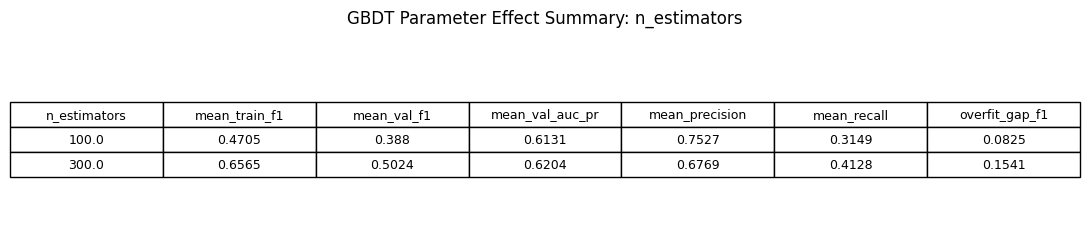


GBDT parameter effect summary: max_depth
   max_depth  mean_train_f1  mean_val_f1  mean_val_auc_pr  mean_precision  \
0          3         0.4622       0.4111           0.6131          0.7359   
1          6         0.6647       0.4793           0.6205          0.6937   

   mean_recall  overfit_gap_f1  
0       0.3293          0.0511  
1       0.3984          0.1854  


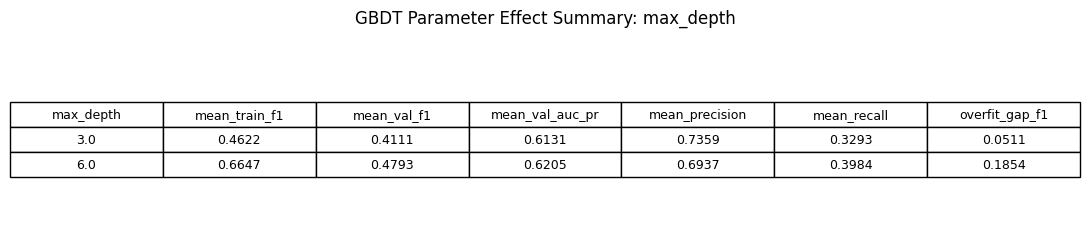


GBDT parameter effect summary: subsample
   subsample  mean_train_f1  mean_val_f1  mean_val_auc_pr  mean_precision  \
0        0.8         0.5665       0.4452           0.6165          0.7144   
1        1.0         0.5605       0.4451           0.6170          0.7152   

   mean_recall  overfit_gap_f1  
0       0.3652          0.1213  
1       0.3625          0.1154  


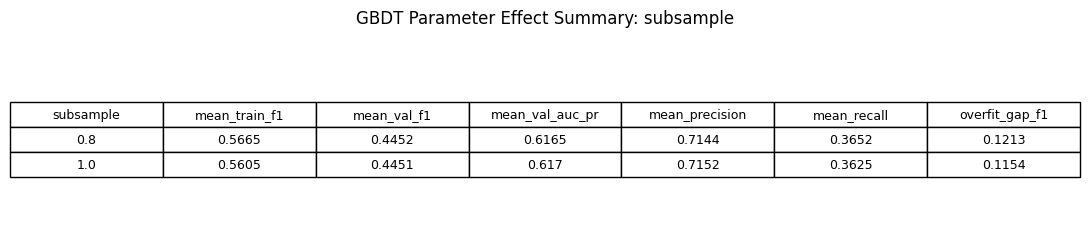


GBDT parameter effect summary: reg_alpha
   reg_alpha  mean_train_f1  mean_val_f1  mean_val_auc_pr  mean_precision  \
0        0.0         0.5634       0.4451           0.6175          0.7146   
1        0.1         0.5642       0.4452           0.6165          0.7147   
2        0.5         0.5629       0.4452           0.6164          0.7151   

   mean_recall  overfit_gap_f1  
0       0.3636          0.1183  
1       0.3642          0.1190  
2       0.3638          0.1177  


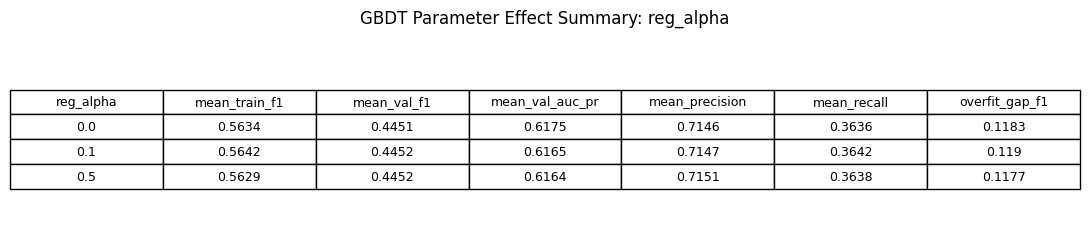


GBDT parameter effect summary: reg_lambda
   reg_lambda  mean_train_f1  mean_val_f1  mean_val_auc_pr  mean_precision  \
0         0.5         0.5753       0.4483           0.6142          0.7124   
1         1.0         0.5704       0.4478           0.6153          0.7150   
2         5.0         0.5447       0.4394           0.6208          0.7170   

   mean_recall  overfit_gap_f1  
0       0.3664          0.1270  
1       0.3659          0.1226  
2       0.3592          0.1053  


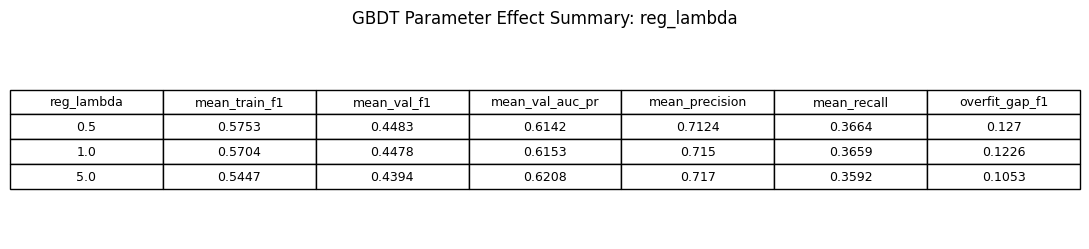

In [193]:
gbdt_parameters_to_summarize = [
    "learning_rate",
    "n_estimators",
    "max_depth",
    "subsample",
    "reg_alpha",
    "reg_lambda",
]

for parameter_name in gbdt_parameters_to_summarize:
    print(f"\nGBDT parameter effect summary: {parameter_name}")
    parameter_summary_df = summarize_gbdt_parameter_effects(
        gbdt_tuning_results_df,
        parameter_name,
    )
    print(parameter_summary_df)
    plot_gbdt_parameter_summary_table(parameter_summary_df, parameter_name)

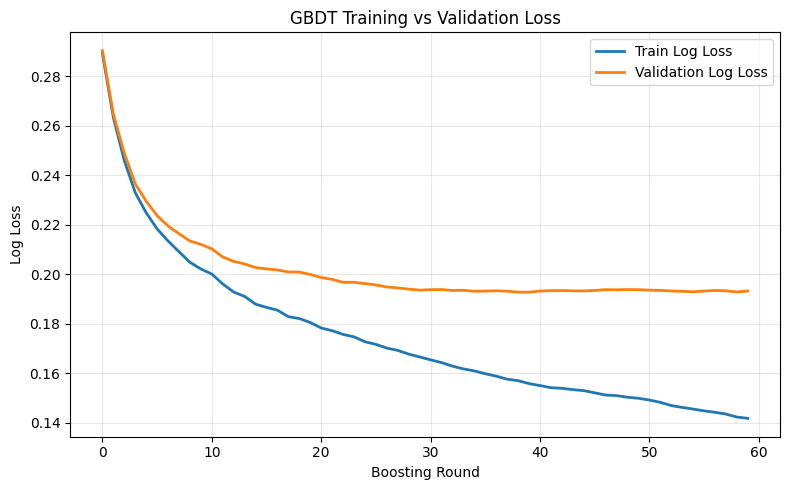

In [194]:
gbdt_monitoring_params = {
    "learning_rate": gbdt_best_metrics["learning_rate"],
    "n_estimators": gbdt_best_metrics["n_estimators"],
    "max_depth": gbdt_best_metrics["max_depth"],
    "subsample": gbdt_best_metrics["subsample"],
    "reg_alpha": gbdt_best_metrics["reg_alpha"],
    "reg_lambda": gbdt_best_metrics["reg_lambda"],
}

gbdt_monitor_start_time = time.time()
gbdt_monitored_model = fit_gbdt_with_monitoring(
    X_train_gbdt,
    y_train,
    X_val_gbdt,
    y_val,
    gbdt_monitoring_params,
    early_stopping_rounds=20,
)
gbdt_monitored_train_time_sec = time.time() - gbdt_monitor_start_time

gbdt_eval_results = gbdt_monitored_model.evals_result()
train_logloss = gbdt_eval_results["validation_0"]["logloss"]
val_logloss = gbdt_eval_results["validation_1"]["logloss"]

plt.figure(figsize=(8, 5))
plt.plot(train_logloss, label="Train Log Loss", linewidth=2)
plt.plot(val_logloss, label="Validation Log Loss", linewidth=2)
plt.title("GBDT Training vs Validation Loss")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VIS_DIR / "gbdt_train_vs_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

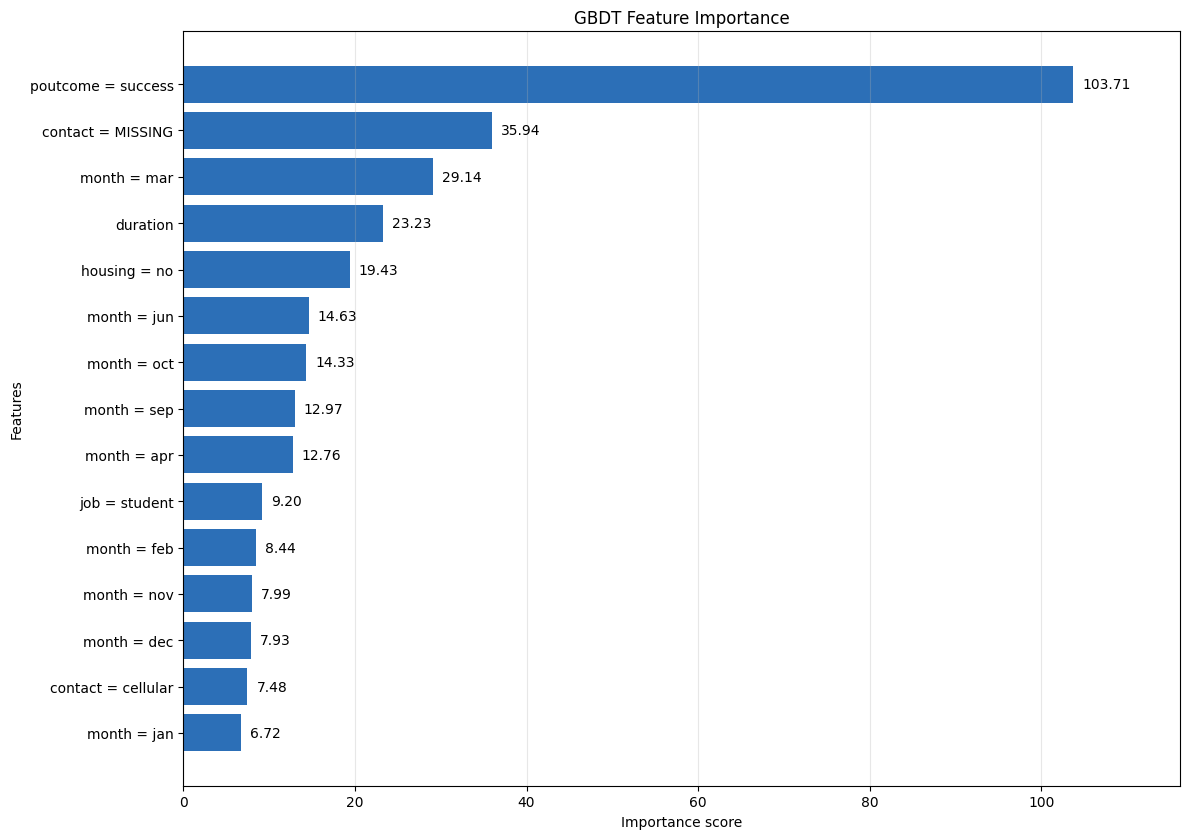

In [195]:
gbdt_feature_names = get_transformed_feature_names(
    gbdt_preprocessor,
    categorical_cols,
)
plot_named_feature_importance(
    gbdt_monitored_model,
    gbdt_feature_names,
    max_num_features=15,
)

GBDT learning rate comparison:
   learning_rate  best_iteration    val_f1  val_auc_pr  min_val_logloss
0           0.01              99  0.142529    0.594830         0.251415
1           0.10              98  0.547099    0.650888         0.192703
2           0.30              39  0.567078    0.647984         0.192762


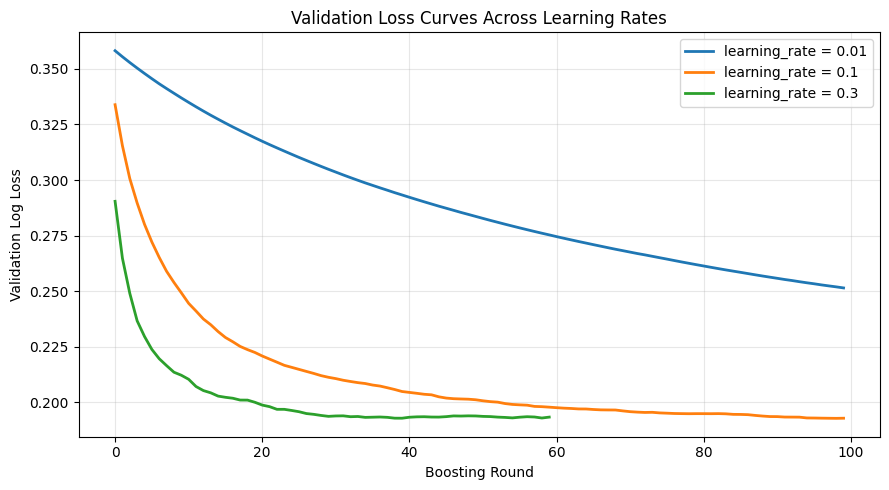

In [196]:
learning_rate_values = [0.01, 0.1, 0.3]
learning_rate_results = []
learning_rate_loss_curves = {}

for learning_rate in learning_rate_values:
    learning_rate_model = fit_gbdt_with_monitoring(
        X_train_gbdt,
        y_train,
        X_val_gbdt,
        y_val,
        {
            "learning_rate": learning_rate,
            "n_estimators": gbdt_best_metrics["n_estimators"],
            "max_depth": gbdt_best_metrics["max_depth"],
            "subsample": gbdt_best_metrics["subsample"],
            "reg_alpha": gbdt_best_metrics["reg_alpha"],
            "reg_lambda": gbdt_best_metrics["reg_lambda"],
        },
        early_stopping_rounds=20,
    )

    y_val_pred_lr = learning_rate_model.predict(X_val_gbdt)
    y_val_proba_lr = learning_rate_model.predict_proba(X_val_gbdt)[:, 1]
    learning_rate_loss_curves[learning_rate] = learning_rate_model.evals_result()["validation_1"]["logloss"]

    learning_rate_results.append(
        {
            "learning_rate": learning_rate,
            "best_iteration": learning_rate_model.best_iteration,
            "val_f1": f1_score(y_val, y_val_pred_lr, zero_division=0),
            "val_auc_pr": average_precision_score(y_val, y_val_proba_lr),
            "min_val_logloss": min(
                learning_rate_model.evals_result()["validation_1"]["logloss"]
            ),
        }
    )

learning_rate_results_df = pd.DataFrame(learning_rate_results).sort_values("learning_rate")
print("GBDT learning rate comparison:")
print(learning_rate_results_df)

plt.figure(figsize=(9, 5))
for learning_rate in learning_rate_values:
    plt.plot(
        learning_rate_loss_curves[learning_rate],
        label=f"learning_rate = {learning_rate}",
        linewidth=2,
    )
plt.title("Validation Loss Curves Across Learning Rates")
plt.xlabel("Boosting Round")
plt.ylabel("Validation Log Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VIS_DIR / "gbdt_learning_rate_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [197]:
threshold_candidates = [0.3, 0.4, 0.5, 0.6, 0.7]
gbdt_best_val_proba = gbdt_monitored_model.predict_proba(X_val_gbdt)[:, 1]

gbdt_threshold_results_df, gbdt_best_threshold_result = tune_decision_threshold(
    y_val,
    gbdt_best_val_proba,
    threshold_candidates,
)

print("GBDT threshold tuning results:")
print(gbdt_threshold_results_df)

print("\nBest GBDT threshold result:")
print(gbdt_best_threshold_result)

GBDT threshold tuning results:
   threshold  accuracy  precision    recall        f1    auc_pr
0        0.3  0.903421   0.571136  0.702771  0.630152  0.647984
1        0.4  0.910941   0.625661  0.595718  0.610323  0.647984
2        0.5  0.911973   0.668376  0.492443  0.567078  0.647984
3        0.6  0.909171   0.713942  0.374055  0.490909  0.647984
4        0.7  0.902684   0.755725  0.249370  0.375000  0.647984

Best GBDT threshold result:
{'threshold': 0.3, 'accuracy': 0.903420819817163, 'precision': 0.5711361310133061, 'recall': 0.7027707808564232, 'f1': 0.6301524562394127, 'auc_pr': 0.6479841423237277}


In [198]:
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    learning_rate_init=0.001,
    alpha=0.0001,
    early_stopping=True,
    max_iter=600,
    random_state=42,
)

print(mlp_baseline)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64), max_iter=600,
              random_state=42)


In [199]:
start_time = time.time()

mlp_baseline.fit(X_train_mlp, y_train)

mlp_train_time = time.time() - start_time

print(f"Baseline MLP training time: {mlp_train_time:.4f} seconds")

Baseline MLP training time: 1.0802 seconds


In [200]:
y_train_pred_mlp = mlp_baseline.predict(X_train_mlp)
y_val_pred_mlp = mlp_baseline.predict(X_val_mlp)
y_val_proba_mlp = mlp_baseline.predict_proba(X_val_mlp)[:, 1]

mlp_train_accuracy = accuracy_score(y_train, y_train_pred_mlp)

mlp_val_metrics = {
    "accuracy": accuracy_score(y_val, y_val_pred_mlp),
    "precision": precision_score(y_val, y_val_pred_mlp, zero_division=0),
    "recall": recall_score(y_val, y_val_pred_mlp, zero_division=0),
    "f1": f1_score(y_val, y_val_pred_mlp, zero_division=0),
    "auc_pr": average_precision_score(y_val, y_val_proba_mlp),
}

print(f"Baseline MLP training accuracy: {mlp_train_accuracy:.4f}")

print("\nBaseline MLP validation metrics:")
for metric_name, metric_value in mlp_val_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Baseline MLP training accuracy: 0.9178

Baseline MLP validation metrics:
accuracy: 0.9086
precision: 0.6399
recall: 0.5013
f1: 0.5621
auc_pr: 0.6145


In [201]:
mlp_tuning_results_df, mlp_best_metrics, mlp_best_pipeline = tune_mlp_hyperparameters(
    X_train,
    y_train,
    X_val,
    y_val,
    numeric_cols,
    categorical_cols,
)

print("Top 5 tuned MLP runs by validation F1:")
print(mlp_tuning_results_df.head(5))

print("\nBest tuned MLP result:")
print(mlp_best_metrics)

Top 5 tuned MLP runs by validation F1:
  hidden_layer_sizes activation  learning_rate_init  max_iter     cv_f1  \
0     (256, 128, 64)       tanh               0.001       300  0.553472   
1     (256, 128, 64)       tanh               0.001       600  0.553472   
2          (128, 64)       tanh               0.001       300  0.526478   
3          (128, 64)       tanh               0.001       600  0.526478   
4              (64,)       relu               0.100       300  0.534829   

   cv_f1_std  rank_test_score  train_accuracy  train_f1  accuracy  precision  \
0   0.028649                5        0.913799  0.615883  0.911531   0.636236   
1   0.028649                5        0.913799  0.615883  0.911531   0.636236   
2   0.037614               19        0.918760  0.645428  0.908582   0.617568   
3   0.037614               19        0.918760  0.645428  0.908582   0.617568   
4   0.021786               13        0.908522  0.597749  0.905780   0.610242   

     recall        f1    auc_

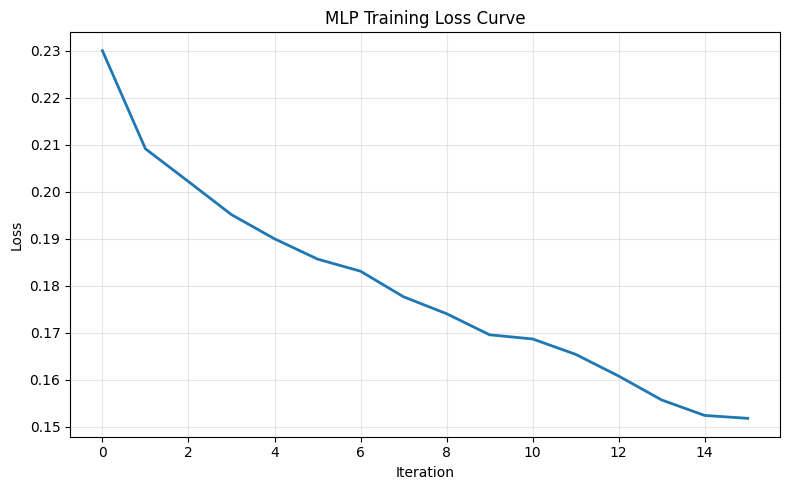

In [202]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_best_pipeline.named_steps["model"].loss_curve_, linewidth=2)
plt.title("MLP Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VIS_DIR / "mlp_training_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

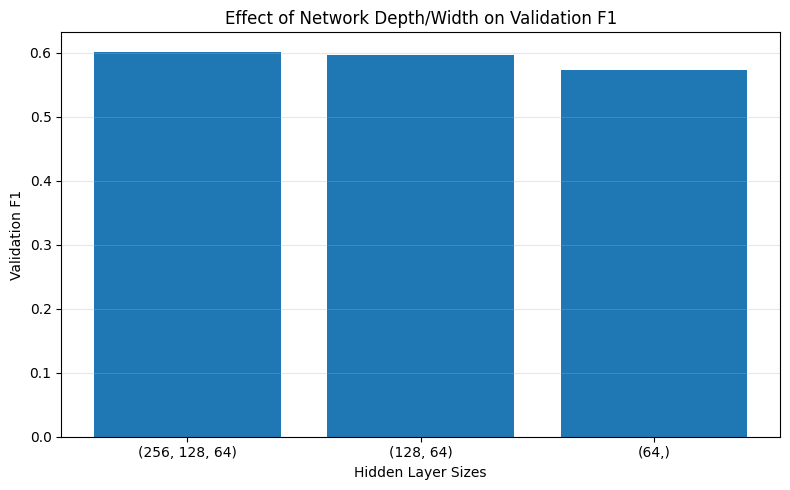

In [203]:
depth_width_performance = (
    mlp_tuning_results_df.groupby("hidden_layer_sizes", as_index=False)["f1"]
    .max()
    .sort_values("f1", ascending=False)
)

architecture_labels = [str(architecture) for architecture in depth_width_performance["hidden_layer_sizes"]]

plt.figure(figsize=(8, 5))
plt.bar(architecture_labels, depth_width_performance["f1"])
plt.title("Effect of Network Depth/Width on Validation F1")
plt.xlabel("Hidden Layer Sizes")
plt.ylabel("Validation F1")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(VIS_DIR / "mlp_depth_width_validation_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [204]:
target_mlp_architecture = (128, 64)
target_mlp_architecture_results = mlp_tuning_results_df[
    mlp_tuning_results_df["hidden_layer_sizes"] == target_mlp_architecture
].sort_values(["f1", "auc_pr"], ascending=False)

if target_mlp_architecture_results.empty:
    print(f"No tuned MLP runs found for hidden_layer_sizes = {target_mlp_architecture}.")
else:
    best_target_mlp_result = target_mlp_architecture_results.iloc[0]

    print(f"Best tuned MLP run for hidden_layer_sizes = {target_mlp_architecture}:")
    print(
        best_target_mlp_result[
            [
                "hidden_layer_sizes",
                "activation",
                "learning_rate_init",
                "max_iter",
                "train_accuracy",
                "train_f1",
                "accuracy",
                "precision",
                "recall",
                "f1",
                "auc_pr",
                "train_time_sec",
            ]
        ]
    )

    print(f"\nOverfitting check for best hidden_layer_sizes = {target_mlp_architecture} MLP:")
    print(f"Training accuracy: {best_target_mlp_result['train_accuracy']:.4f}")
    print(f"Validation accuracy: {best_target_mlp_result['accuracy']:.4f}")
    print(f"Training F1: {best_target_mlp_result['train_f1']:.4f}")
    print(f"Validation F1: {best_target_mlp_result['f1']:.4f}")

Best tuned MLP run for hidden_layer_sizes = (128, 64):
hidden_layer_sizes    (128, 64)
activation                 tanh
learning_rate_init        0.001
max_iter                    300
train_accuracy          0.91876
train_f1               0.645428
accuracy               0.908582
precision              0.617568
recall                 0.575567
f1                     0.595828
auc_pr                 0.634143
train_time_sec         1.868671
Name: 2, dtype: object

Overfitting check for best hidden_layer_sizes = (128, 64) MLP:
Training accuracy: 0.9188
Validation accuracy: 0.9086
Training F1: 0.6454
Validation F1: 0.5958


In [205]:
mlp_best_val_proba = mlp_best_pipeline.predict_proba(X_val)[:, 1]

mlp_threshold_results_df, mlp_best_threshold_result = tune_decision_threshold(
    y_val,
    mlp_best_val_proba,
    threshold_candidates,
)

print("MLP threshold tuning results:")
print(mlp_threshold_results_df)

print("\nBest MLP threshold result:")
print(mlp_best_threshold_result)

MLP threshold tuning results:
   threshold  accuracy  precision    recall        f1    auc_pr
0        0.3  0.895016   0.537546  0.739295  0.622481  0.622997
1        0.4  0.905780   0.587968  0.652393  0.618507  0.622997
2        0.5  0.909761   0.644904  0.510076  0.569620  0.622997
3        0.6  0.907254   0.698795  0.365239  0.479735  0.622997
4        0.7  0.902684   0.768000  0.241814  0.367816  0.622997

Best MLP threshold result:
{'threshold': 0.3, 'accuracy': 0.8950162194043055, 'precision': 0.5375457875457875, 'recall': 0.739294710327456, 'f1': 0.6224814422057264, 'auc_pr': 0.6229974434317797}


In [206]:
final_gbdt_model = gbdt_monitored_model
final_gbdt_threshold = gbdt_best_threshold_result["threshold"]

final_mlp_model = mlp_best_pipeline
final_mlp_threshold = mlp_best_threshold_result["threshold"]

print("Final GBDT configuration:")
print(gbdt_best_metrics)
print(f"Final GBDT threshold: {final_gbdt_threshold}")

print("\nFinal MLP configuration:")
print(mlp_best_metrics)
print(f"Final MLP threshold: {final_mlp_threshold}")

Final GBDT configuration:
{'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 5.0, 'subsample': 1.0, 'accuracy': 0.9107932763196697, 'precision': 0.6567164179104478, 'recall': 0.4987405541561713, 'f1': 0.5669291338582677, 'auc_pr': 0.6414706296549143, 'train_time_sec': 0.2585132122039795, 'search_time_sec': 27.63472819328308}
Final GBDT threshold: 0.3

Final MLP configuration:
{'activation': 'relu', 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01, 'max_iter': 300, 'train_accuracy': 0.9169273548835593, 'train_f1': 0.6142333088774762, 'accuracy': 0.9097611324093188, 'precision': 0.6449044585987261, 'recall': 0.5100755667506297, 'f1': 0.569620253164557, 'auc_pr': 0.6229974434317797, 'train_time_sec': 0.8711631298065186, 'search_time_sec': 15.3680739402771}
Final MLP threshold: 0.3


In [207]:
gbdt_cv_model = build_model_pipeline(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    scale_numeric=False,
    model=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        colsample_bytree=1.0,
        random_state=42,
        learning_rate=gbdt_best_metrics["learning_rate"],
        n_estimators=gbdt_best_metrics["n_estimators"],
        max_depth=gbdt_best_metrics["max_depth"],
        subsample=gbdt_best_metrics["subsample"],
        reg_alpha=gbdt_best_metrics["reg_alpha"],
        reg_lambda=gbdt_best_metrics["reg_lambda"],
    ),
)

mlp_cv_model = build_model_pipeline(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    scale_numeric=True,
    model=MLPClassifier(
        early_stopping=True,
        random_state=42,
        hidden_layer_sizes=mlp_best_metrics["hidden_layer_sizes"],
        activation=mlp_best_metrics["activation"],
        learning_rate_init=mlp_best_metrics["learning_rate_init"],
        max_iter=mlp_best_metrics["max_iter"],
    ),
)

gbdt_cv_scores = cross_val_score(
    gbdt_cv_model,
    X_train,
    y_train,
    cv=3,
    scoring="f1",
    n_jobs=-1,
)
mlp_cv_scores = cross_val_score(
    mlp_cv_model,
    X_train,
    y_train,
    cv=3,
    scoring="f1",
    n_jobs=-1,
)

cv_summary_df = pd.DataFrame(
    [
        {
            "model": "GBDT",
            "cv_f1_mean": round(gbdt_cv_scores.mean(), 4),
            "cv_f1_std": round(gbdt_cv_scores.std(), 4),
        },
        {
            "model": "MLP",
            "cv_f1_mean": round(mlp_cv_scores.mean(), 4),
            "cv_f1_std": round(mlp_cv_scores.std(), 4),
        },
    ]
)

print("Cross-validation F1 summary:")
print(cv_summary_df)

Cross-validation F1 summary:
  model  cv_f1_mean  cv_f1_std
0  GBDT      0.5543     0.0052
1   MLP      0.5630     0.0089


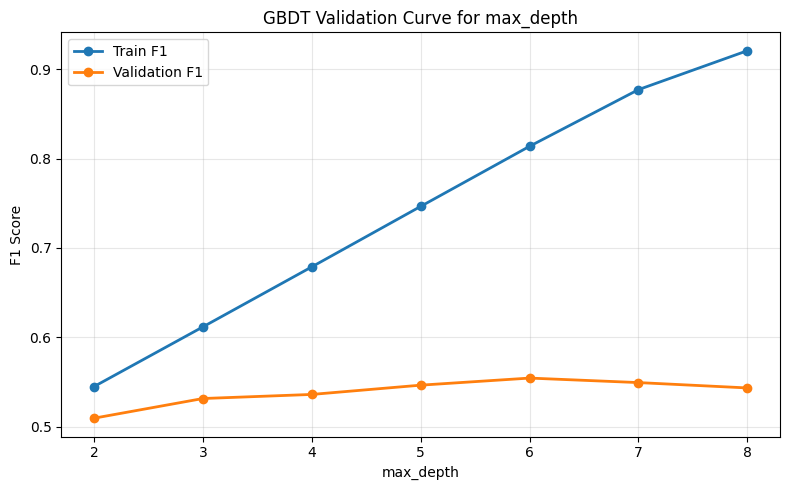

In [208]:
# Additional diagnostic beyond the tuned search grid: sweep a wider range of
# max_depth values so the validation-curve plot is informative rather than a
# two-point comparison.
gbdt_validation_curve_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            build_preprocessor(
                numeric_cols=numeric_cols,
                categorical_cols=categorical_cols,
                scale_numeric=False,
            ),
        ),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                colsample_bytree=1.0,
                random_state=42,
                learning_rate=gbdt_best_metrics["learning_rate"],
                n_estimators=gbdt_best_metrics["n_estimators"],
                subsample=gbdt_best_metrics["subsample"],
                reg_alpha=gbdt_best_metrics["reg_alpha"],
                reg_lambda=gbdt_best_metrics["reg_lambda"],
            ),
        ),
    ]
)

depth_param_range = [2, 3, 4, 5, 6, 7, 8]
gbdt_train_scores, gbdt_val_scores = validation_curve(
    gbdt_validation_curve_pipeline,
    X_train,
    y_train,
    param_name="model__max_depth",
    param_range=depth_param_range,
    cv=3,
    scoring="f1",
    n_jobs=-1,
)

gbdt_train_mean = gbdt_train_scores.mean(axis=1)
gbdt_val_mean = gbdt_val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(depth_param_range, gbdt_train_mean, marker="o", linewidth=2, label="Train F1")
plt.plot(depth_param_range, gbdt_val_mean, marker="o", linewidth=2, label="Validation F1")
plt.title("GBDT Validation Curve for max_depth")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(VIS_DIR / "gbdt_validation_curve_max_depth.png", dpi=300, bbox_inches="tight")
plt.show()

In [209]:
final_gbdt_test_metrics = evaluate_model_on_test_set(
    final_gbdt_model,
    X_test_gbdt,
    y_test,
    threshold=final_gbdt_threshold,
)
final_gbdt_test_metrics["train_time_sec"] = gbdt_monitored_train_time_sec

final_mlp_test_metrics = evaluate_model_on_test_set(
    final_mlp_model,
    X_test,
    y_test,
    threshold=final_mlp_threshold,
)
final_mlp_test_metrics["train_time_sec"] = mlp_best_metrics["train_time_sec"]

print("Final GBDT test metrics:")
print(final_gbdt_test_metrics)

print("\nFinal MLP test metrics:")
print(final_mlp_test_metrics)

Final GBDT test metrics:
{'accuracy': 0.8969330580949573, 'precision': 0.5445075757575758, 'recall': 0.725094577553594, 'f1': 0.6219578150351541, 'auc_pr': 0.6069836582032682, 'train_time_sec': 0.15838217735290527}

Final MLP test metrics:
{'accuracy': 0.8888233559422, 'precision': 0.5165675446049278, 'recall': 0.7667087011349306, 'f1': 0.617258883248731, 'auc_pr': 0.582259836536764, 'train_time_sec': 0.8711631298065186}


Final GBDT vs MLP comparison table:
  model  accuracy  precision  recall      f1  auc_pr  train_time_sec
0  GBDT    0.8969     0.5445  0.7251  0.6220  0.6070          0.1584
1   MLP    0.8888     0.5166  0.7667  0.6173  0.5823          0.8712


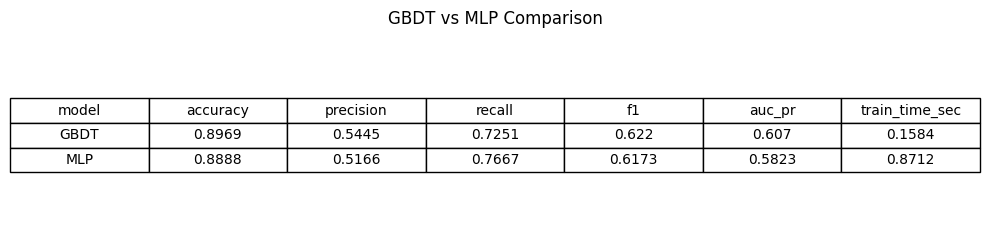


Final comparison summary:
           metric best_model  best_value
0        accuracy       GBDT      0.8969
1       precision       GBDT      0.5445
2          recall        MLP      0.7667
3              f1       GBDT      0.6220
4          auc_pr       GBDT      0.6070
5  train_time_sec       GBDT      0.1584


In [210]:
final_comparison_table = build_comparison_table(
    final_gbdt_test_metrics,
    final_mlp_test_metrics,
)

print("Final GBDT vs MLP comparison table:")
print(final_comparison_table)
plot_comparison_table(final_comparison_table)

final_comparison_summary = summarize_final_model_comparison(final_comparison_table)
print("\nFinal comparison summary:")
print(final_comparison_summary)